## Taking Gradients Reworked

In [59]:
from Modules.gradients import take_grad
from Modules.Neural_Net import Net
import torch

time = 30.2
model_config = torch.load('nets/MSE/SIREN.pt', weights_only=False)
input_unscaled = torch.load('Modules/plotting_region.pt', weights_only=True)
input_unscaled = torch.cat([input_unscaled, time*torch.ones_like(input_unscaled[:, :1])], dim=1)

scaler_in, scaler_out = model_config['scalers']

# Properly scale using the scaler
input_scaled = torch.tensor(scaler_in.transform(input_unscaled.numpy()), 
                            dtype=torch.float32).requires_grad_(True)

net = Net(torch.sin, *model_config['model config'])
net.load_state_dict(model_config['model_state_dict'])
net.eval()

output_scaled = net(input_scaled)

# Get scaling factors for chain rule
in_scale = torch.tensor(scaler_in.scale_, dtype=torch.float32)
out_scale = torch.tensor(scaler_out.scale_, dtype=torch.float32)

# Compute gradients in scaled space
gradient_scaled = take_grad(input_scaled, output_scaled)
grads_scaled = gradient_scaled.grad()

# Convert to unscaled space using chain rule:
# d(output_unscaled)/d(input_unscaled) = d(output_scaled)/d(input_scaled) * (out_scale / in_scale)
grads_unscaled = grads_scaled * (out_scale.unsqueeze(0) / in_scale.unsqueeze(0))

dx = grads_unscaled[:, 0:1]
dy = grads_unscaled[:, 1:2]

g_2 = torch.sqrt(dx**2 + dy**2)

# Optional: unscale output if you need it
output_unscaled = torch.tensor(scaler_out.inverse_transform(output_scaled.detach().numpy()), 
                               dtype=torch.float32)

6.9042516 0.2718749


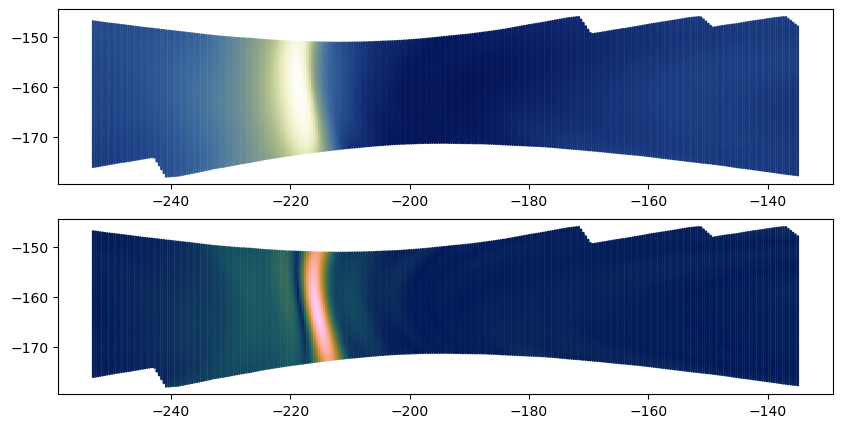

In [ ]:
import matplotlib.pyplot as plt
import cmcrameri.cm as cmc 
import numpy as np

z = output_unscaled.detach().cpu().numpy().reshape(-1,1)
dz = g_2.detach().cpu().numpy().reshape(-1,1)
x = input_unscaled[:,0].detach().cpu().numpy().reshape(-1,1)
y = input_unscaled[:,1].detach().cpu().numpy().reshape(-1,1)

fig, (ax1, ax2) = plt.subplots(2, figsize=(10, 5))

ax1.scatter(x, y, c=z, s=1, cmap=cmc.davos, vmin=0, vmax=7)
ax2.scatter(x, y, c=dz, s=1, cmap=cmc.batlow)


#### Similar plotting technique, but we are making gradient estimations

- Take $ \frac{\partial \eta}{\partial y}$  and  $ \frac{\partial \eta}{\partial t}$
- Plot as a function fixed in space
- Once gotten make a circle around fixed point in space and increase radius outwards and see affects on average gradients

In [1]:
'modules needed'

import torch
from Modules import pre_pro
from Modules.Neural_Net import Net
from Modules.Neural_Net import NetWrapper
from tqdm import tqdm
import matplotlib.pyplot as plt
import cmcrameri.cm as cmc
from Modules.gradients import gradient_inputs
from Modules.gradients import circle_meth
from Modules.gradients import take_grad
import numpy as np
k=0


In [2]:
'net work'

network_info = torch.load('nets/MSE/mse_250_350.pt', weights_only=True)
model_config = network_info['model config']
net = Net(torch.cos, *model_config)
net.load_state_dict(network_info['model_state_dict'])

device = 'cpu'
net = net.to(device)
cp = [-180,-160, 2.5]


print('done')

done


Lets look at the average gradients at where we are evaluating
$$ \frac1n \sum_{i = 1}^n \|\nabla f\|$$

In [3]:
grad_comp = circle_meth(cp, net)
grads = grad_comp.spt_grad(.05, 15)

In [4]:
input = torch.load('Modules/plotting_region.pt', weights_only=True).to(torch.float32)
def add_time(tensor, time):
    shape = torch.ones_like(tensor[:,1:2])
    return torch.hstack((tensor,shape*time ))
inputs = add_time(input, 30)
inputs = inputs.requires_grad_(True)
grad_out = net(inputs)

operator = take_grad(inputs, grad_out)
grads = operator.grad()

<>:11: SyntaxWarning: invalid escape sequence '\e'
<>:11: SyntaxWarning: invalid escape sequence '\e'
C:\Users\dculv\AppData\Local\Temp\ipykernel_68772\2607429138.py:11: SyntaxWarning: invalid escape sequence '\e'
  ax1.set_title('$\eta$', fontsize=16, fontweight='bold')


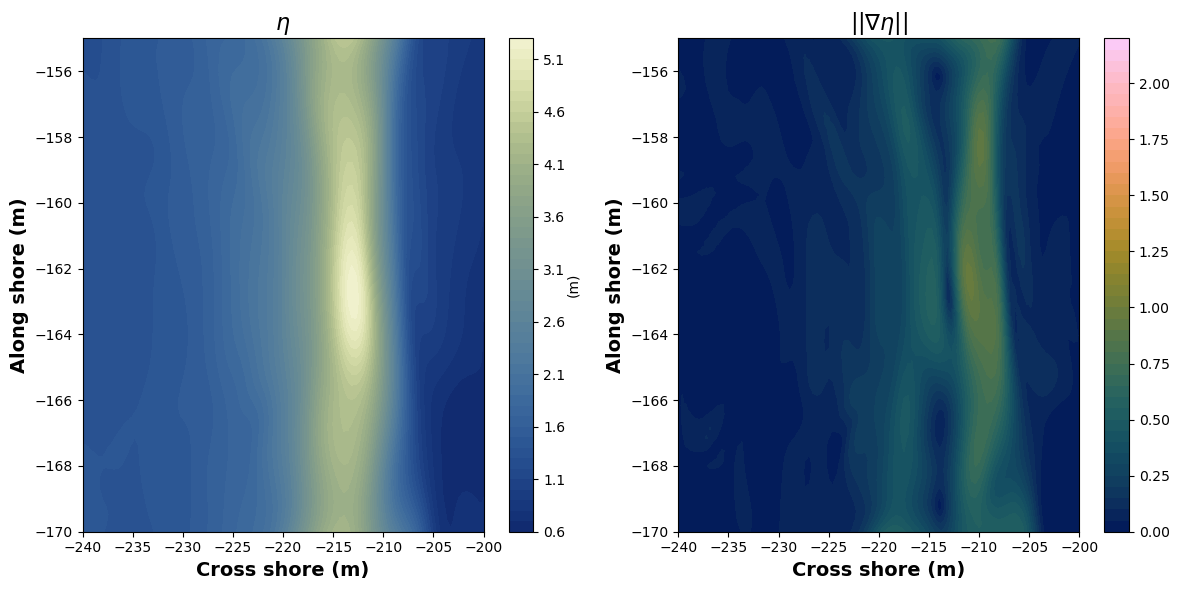

'make to surface plots. One is with (x,y,z) other is (x,y,grad_z)'

In [5]:


x = inputs[:,0].detach().cpu().numpy().reshape(-1,1)
y = inputs[:,1].detach().cpu().numpy().reshape(-1,1)

z = grad_out.detach().cpu().numpy().reshape(-1,1)

grad_xy = np.sqrt(grads[:,0].detach().cpu().numpy().reshape(-1,1)**2+grads[:,1].detach().cpu().numpy().reshape(-1,1)**2)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,6))

surf1 = ax1.tricontourf(x.flatten(), y.flatten(), z.flatten(), cmap=cmc.davos, vmin=0, vmax=6, levels=50)
ax1.set_title('$\eta$', fontsize=16, fontweight='bold')
ax1.set_xlim(-240, -200)
ax1.set_ylim(-170, -155)
ax1.set_xlabel('Cross shore (m)', fontsize = 14, fontweight = 'bold')
ax1.set_ylabel('Along shore (m)', fontsize = 14, fontweight = 'bold')

cbar = fig.colorbar(surf1, ax=ax1, aspect=20)
cbar.set_label('(m)',  labelpad=1)

surf2 = ax2.tricontourf(x.flatten(), y.flatten(), grad_xy.flatten(), cmap=cmc.batlow, levels=50)
ax2.set_title(r'$||\nabla \eta||$',  fontsize=16, fontweight='bold')
ax2.set_xlim(-240, -200)
ax2.set_ylim(-170, -155)
ax2.set_xlabel('Cross shore (m)', fontsize = 14, fontweight = 'bold')
ax2.set_ylabel('Along shore (m)', fontsize = 14, fontweight = 'bold')

fig.colorbar(surf2, ax=ax2, aspect=20)
plt.tight_layout()
plt.show()



'make to surface plots. One is with (x,y,z) other is (x,y,grad_z)'

<>:4: SyntaxWarning: invalid escape sequence '\e'
<>:4: SyntaxWarning: invalid escape sequence '\e'
C:\Users\dculv\AppData\Local\Temp\ipykernel_82600\1908271855.py:4: SyntaxWarning: invalid escape sequence '\e'
  ax1.set_title('$\eta$', fontsize=16, fontweight='bold')


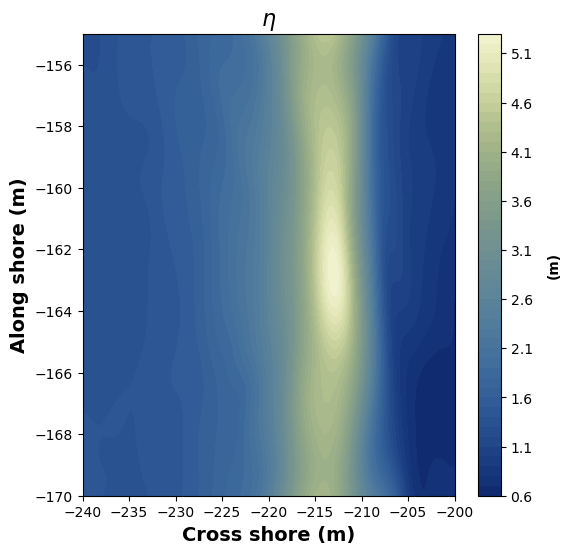

In [6]:
fig, (ax1) = plt.subplots( figsize=(6,6))

surf1 = ax1.tricontourf(x.flatten(), y.flatten(), z.flatten(), cmap=cmc.davos, vmin=0, vmax=6, levels=50)
ax1.set_title('$\eta$', fontsize=16, fontweight='bold')
ax1.set_xlim(-240, -200)
ax1.set_ylim(-170, -155)
ax1.set_xlabel('Cross shore (m)', fontsize = 14, fontweight = 'bold')
ax1.set_ylabel('Along shore (m)', fontsize = 14, fontweight = 'bold')

cbar = fig.colorbar(surf1, ax=ax1, aspect=20)
cbar.set_label('(m)',  labelpad=10, fontweight='bold')

plt.show()

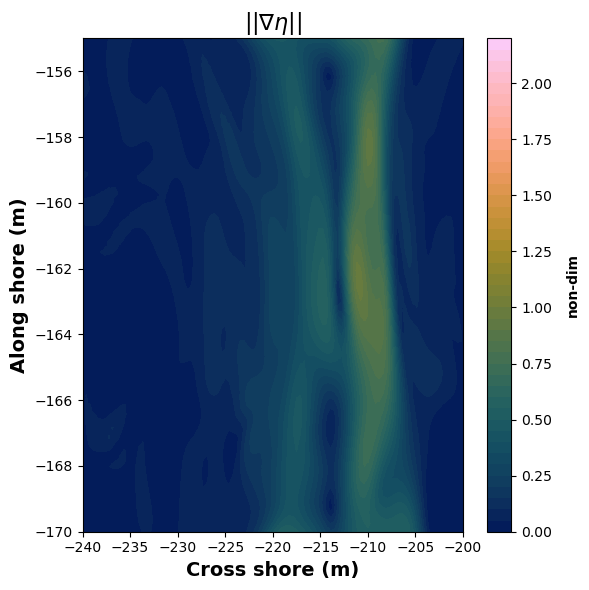

In [7]:
fig, (ax2) = plt.subplots( figsize=(6,6))

surf2 = ax2.tricontourf(x.flatten(), y.flatten(), grad_xy.flatten(), cmap=cmc.batlow, levels=50)
ax2.set_title(r'$||\nabla \eta||$',  fontsize=16, fontweight='bold')
ax2.set_xlim(-240, -200)
ax2.set_ylim(-170, -155)
ax2.set_xlabel('Cross shore (m)', fontsize = 14, fontweight = 'bold')
ax2.set_ylabel('Along shore (m)', fontsize = 14, fontweight = 'bold')

cbar = fig.colorbar(surf2, ax=ax2, aspect=20)
cbar.set_label('non-dim',  labelpad=10, fontweight='bold')
plt.tight_layout()


plt.show()

In [9]:
x = inputs[:,0].detach().cpu().numpy().reshape(-1,1)
y = inputs[:,1].detach().cpu().numpy().reshape(-1,1)
z = grad_out.detach().cpu().numpy().reshape(-1,1)
grad_xy = np.sqrt(grads[:,0].detach().cpu().numpy().reshape(-1,1)**2+grads[:,1].detach().cpu().numpy().reshape(-1,1)**2)

mask = (y > -160.5) & (y < -159.5)

x = x[mask]
z = z[mask]
z = grad_xy[mask]





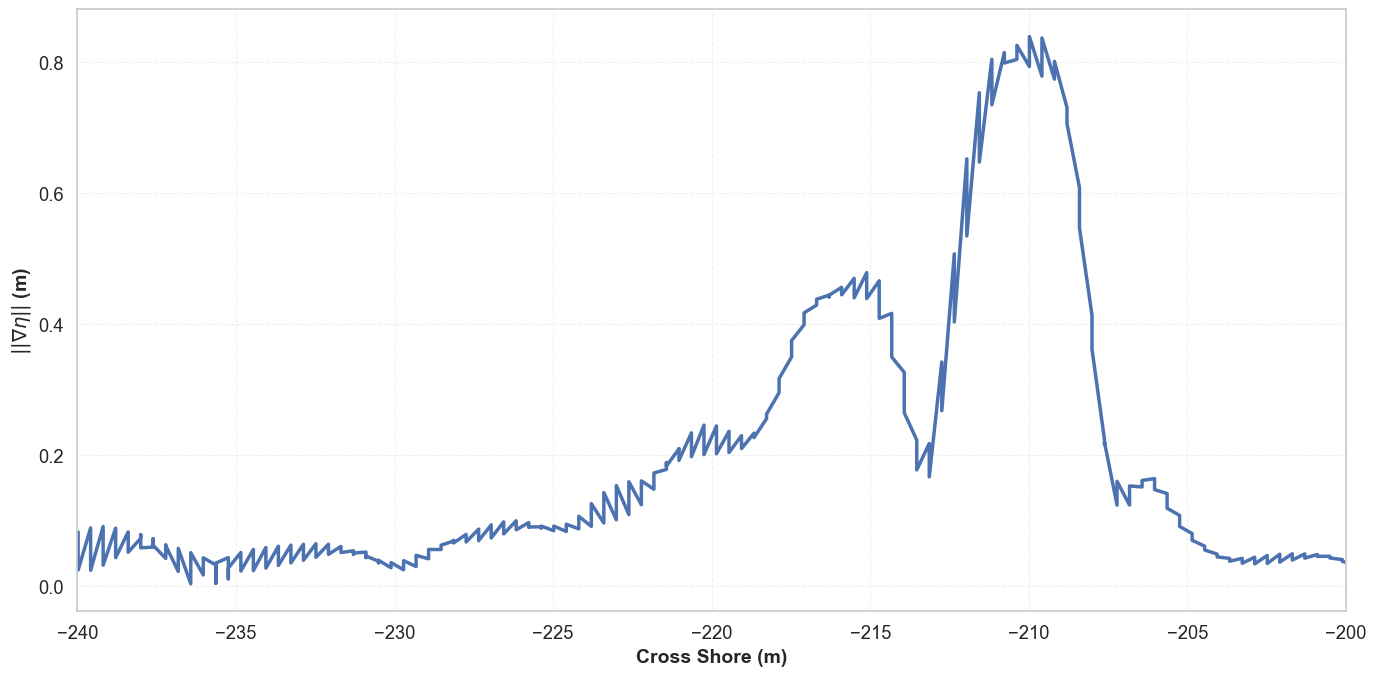

In [10]:

'Sea Surface'
import seaborn as sns
# Set seaborn style
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.2)

# Create figure with seaborn styling
fig, ax = plt.subplots(figsize=(14, 7))

# Plot with seaborn color palette
ax.plot(x, z, linewidth=2.5, color=sns.color_palette("deep")[0], label='Sea Surface')

# Styling
ax.set_xlabel('Cross Shore (m)', fontsize=14, fontweight='bold')
ax.set_ylabel(r'$ || \nabla \eta|| $ (m)', fontsize=14, fontweight='bold')


# Add grid with custom styling
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.8)


ax.set_xlim(-240, -200)
plt.tight_layout()
plt.show()